# `scitex-nn` — module tour

A narrative walk through the most-used modules in `scitex-nn`. Each
section exercises one class on a small synthetic signal and renders
the result inline. Run cell-by-cell or use the runnable `.py`
siblings under `examples/` for headless reproduction.

**Convention**: every signal-processing layer takes a tensor shaped
`(batch, channels, samples)` and operates on the last axis.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import chirp
from scipy.signal import hilbert as scipy_hilbert

import scitex_nn

torch.manual_seed(0)
np.random.seed(0)

fs = 500
duration = 1.0
seq_len = int(fs * duration)
t = np.arange(seq_len) / fs

## 1 · `Hilbert` — analytic-signal envelope

`scitex_nn.Hilbert` returns the analytic-signal phase and amplitude
stacked along a new last dimension. Output matches
`scipy.signal.hilbert` to float-32 noise.

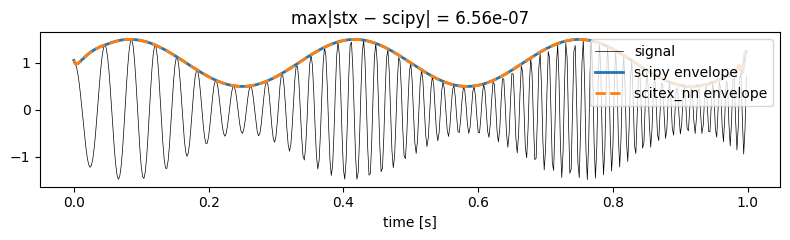

In [2]:
sig = chirp(t, f0=20, t1=t[-1], f1=100) * (1 + 0.5 * np.sin(2 * np.pi * 3 * t))
sig = sig.astype(np.float32)

H = scitex_nn.Hilbert(seq_len=seq_len, dim=-1)
out = H(torch.from_numpy(sig)).numpy()
amp_stx = out[..., 1]
amp_scipy = np.abs(scipy_hilbert(sig))

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t, sig, "k", lw=0.5, label="signal")
ax.plot(t, amp_scipy, lw=2, label="scipy envelope")
ax.plot(t, amp_stx, "--", lw=2, label="scitex_nn envelope")
ax.legend(loc="upper right")
ax.set_xlabel("time [s]")
ax.set_title(f"max|stx − scipy| = {np.abs(amp_stx - amp_scipy).max():.2e}")
fig.tight_layout()
plt.show()

## 2 · `GaussianFilter` — temporal smoothing

Convolves the last axis with a Gaussian kernel of size `6·sigma`.
Larger `sigma` ⇒ stronger smoothing ⇒ more attenuation of both noise
and the signal high-frequency content.

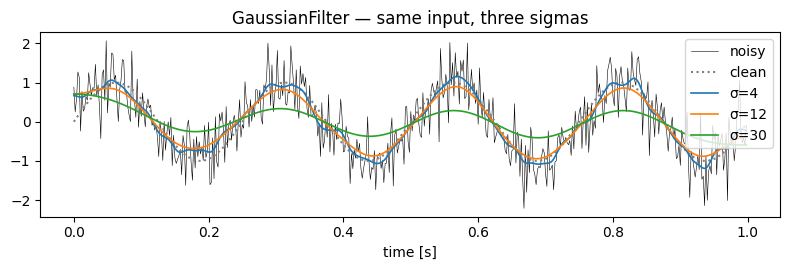

In [3]:
clean = np.sin(2 * np.pi * 4 * t)
noisy = clean + 0.5 * np.random.randn(seq_len)
x = torch.from_numpy(noisy).float().view(1, 1, -1)

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot(t, noisy, "k", lw=0.4, label="noisy")
ax.plot(t, clean, "grey", ls=":", label="clean")
for sigma in (4, 12, 30):
    y = scitex_nn.GaussianFilter(sigma=sigma)(x).squeeze().numpy()
    ax.plot(t, y, lw=1.2, label=f"σ={sigma}")
ax.legend(loc="upper right")
ax.set_xlabel("time [s]")
ax.set_title("GaussianFilter — same input, three sigmas")
fig.tight_layout()
plt.show()

## 3 · `LowPass` / `HighPass` / `BandPass` / `BandStop`

Push an impulse through each filter; the FFT magnitude of the output
is the frequency response. The vertical lines mark the design
cutoffs.

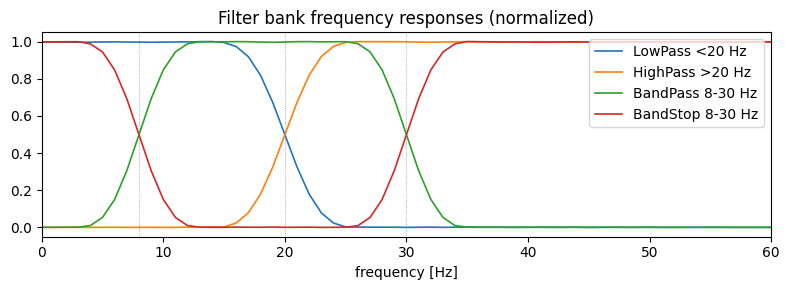

In [4]:
impulse = torch.zeros(1, 1, seq_len)
impulse[0, 0, seq_len // 2] = 1.0
freqs = np.fft.rfftfreq(seq_len, d=1.0 / fs)

bands = torch.tensor([[8.0, 30.0]])
filters = {
    "LowPass <20 Hz": scitex_nn.LowPassFilter(20.0, fs, seq_len),
    "HighPass >20 Hz": scitex_nn.HighPassFilter(20.0, fs, seq_len),
    "BandPass 8-30 Hz": scitex_nn.BandPassFilter(bands, fs, seq_len),
    "BandStop 8-30 Hz": scitex_nn.BandStopFilter(bands, fs, seq_len),
}

fig, ax = plt.subplots(figsize=(8, 3.0))
for name, filt in filters.items():
    y = filt(impulse).detach().numpy().reshape(-1)[:seq_len]
    mag = np.abs(np.fft.rfft(y))
    ax.plot(freqs, mag / mag.max(), lw=1.2, label=name)
for v in (20, 8, 30):
    ax.axvline(v, color="grey", ls=":", lw=0.5)
ax.set_xlim(0, 60)
ax.legend(loc="upper right")
ax.set_xlabel("frequency [Hz]")
ax.set_title("Filter bank frequency responses (normalized)")
fig.tight_layout()
plt.show()

## 4 · `Spectrogram` vs `Wavelet`

`Spectrogram` is fixed-window STFT. `Wavelet` adapts the window
length per carrier frequency (Morlet) — better time resolution at
high frequency, better frequency resolution at low.

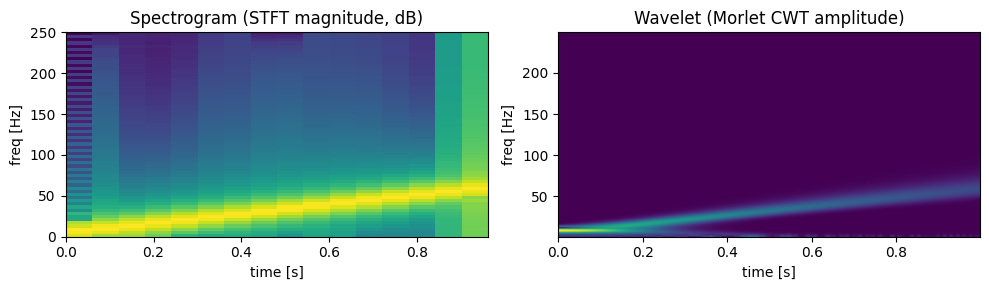

In [5]:
x_chirp = torch.from_numpy(chirp(t, f0=5, t1=t[-1], f1=60).astype(np.float32)).view(
    1, 1, -1
)

sg = scitex_nn.Spectrogram(sampling_rate=fs, n_fft=128)
spec, sf, st = sg(x_chirp)

wav = scitex_nn.Wavelet(samp_rate=fs, freq_scale="linear", out_scale="linear")
_, amp, wf = wav(x_chirp)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0), sharey=False)
axes[0].imshow(
    20 * np.log10(spec.squeeze().numpy() + 1e-9),
    aspect="auto",
    origin="lower",
    extent=(0, float(st[-1]), 0, float(sf[-1])),
    cmap="viridis",
)
axes[0].set_title("Spectrogram (STFT magnitude, dB)")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("freq [Hz]")

freqs_w = wf.squeeze().numpy()
axes[1].imshow(
    amp.squeeze().numpy(),
    aspect="auto",
    origin="lower",
    extent=(0.0, float(t[-1]), float(freqs_w[0]), float(freqs_w[-1])),
    cmap="viridis",
)
axes[1].set_title("Wavelet (Morlet CWT amplitude)")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("freq [Hz]")
fig.tight_layout()
plt.show()

## 5 · `AxiswiseDropout` — slice-wise dropout

Standard `nn.Dropout` zeros individual elements. `AxiswiseDropout`
drops whole slices along one axis. Useful when neighbouring elements
inside a slice are correlated (e.g. samples of one channel).

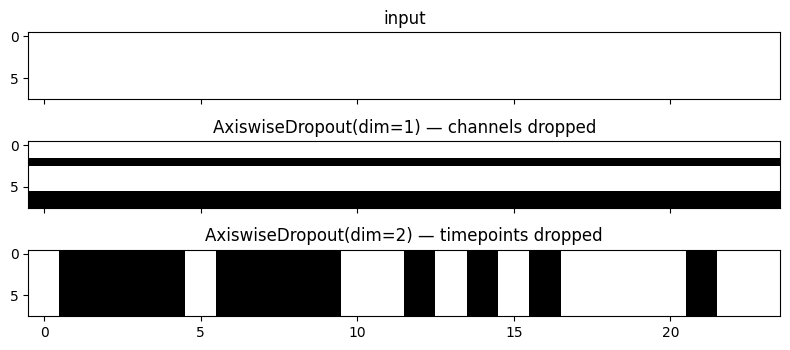

In [6]:
ones = torch.ones(1, 8, 24)
drop_chan = scitex_nn.AxiswiseDropout(dropout_prob=0.5, dim=1).train()
drop_time = scitex_nn.AxiswiseDropout(dropout_prob=0.5, dim=2).train()

fig, axes = plt.subplots(3, 1, figsize=(8, 3.6), sharex=True)
axes[0].imshow(ones[0].numpy(), aspect="auto", cmap="gray_r")
axes[0].set_title("input")
axes[1].imshow(drop_chan(ones)[0].detach().numpy(), aspect="auto", cmap="gray_r")
axes[1].set_title("AxiswiseDropout(dim=1) — channels dropped")
axes[2].imshow(drop_time(ones)[0].detach().numpy(), aspect="auto", cmap="gray_r")
axes[2].set_title("AxiswiseDropout(dim=2) — timepoints dropped")
fig.tight_layout()
plt.show()

## Where to next?

- `examples/<NN>_*.py` — every numbered example is runnable
  headlessly; results land under `examples/<stem>_out/` and the
  curated PNG under `examples/_assets/`.
- `examples/00_run_all.sh` — dispatches every numbered example.
- `examples/10_pac.py` — the heaviest demo: `scitex_nn.PAC` end-to-end
  on synthetic theta-gamma, producing a comodulogram.